# ForgeWM Paper 2 — Experiment 5: Causal Edge Certification

**Core experiment of Paper 2.**

**Goal**: Introduce a genuinely new causal mechanism — temperature-dependent yield stress
σ_y(T) = σ_y0·(1 - α·T) — that is unknown to axiom system A. Show that:

1. PC algorithm discovers the edge T → σ from interventional FEM data
2. Theorem 3 certifies A ⊬ (T causes σ) via a single do(T=t) FEM experiment
3. PySR finds a fit but **cannot certify non-derivability**
4. AI-Descartes (simulated) cannot transcend its axiom system
5. Observational PC may miss the edge due to confounding

## Physical setup
```
True model:  σ = σ_y0·(1 - α·T) + H·(ε - ε_y)  [plastic, T-dependent]
             σ = E·ε                               [elastic]
Axiom A:     σ = σ_y + H·(ε - ε_y)  [plastic, T-independent]
             σ = E·ε                 [elastic]
Missing:     T → σ_y  (temperature weakens yield stress)
```

**Expected runtime**: ~3–4 hours on T4

---

## Cell 1 — Install and Imports

In [1]:
!pip install -q causal-learn pysr scipy scikit-learn matplotlib numpy pandas tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from tqdm.notebook import tqdm
import warnings, json
warnings.filterwarnings('ignore')
print('Imports ready.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.5/245.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 19.6 MB/s eta 0:00:00
Imports ready.


## Cell 2 — FEM Oracle with Temperature-Dependent Yield

In [6]:
LAMBDA_STAR = 0.002
ALPHA_T     = 0.0015  # thermal softening coefficient [1/K]
T_REF       = 300.0   # reference temperature [K]

def sigma_y_thermal(sigma_y0, T, alpha=ALPHA_T):
    """Temperature-dependent yield stress — UNKNOWN to axiom system A."""
    return sigma_y0 * (1.0 - alpha * (T - T_REF))

def constitutive_true(epsilon, Youngs_E, sigma_y0, H, T):
    """True constitutive law including T-dependent yield."""
    sigma_y_eff = sigma_y_thermal(sigma_y0, T)
    sigma_y_eff = max(sigma_y_eff, 10e6)  # floor: 10 MPa
    if epsilon <= LAMBDA_STAR:
        return Youngs_E * epsilon
    return sigma_y_eff + H * (epsilon - LAMBDA_STAR)

def constitutive_axiom(epsilon, Youngs_E, sigma_y0, H, T=None):
    """Axiom system A — does not know about T dependence."""
    if epsilon <= LAMBDA_STAR:
        return Youngs_E * epsilon
    return sigma_y0 + H * (epsilon - LAMBDA_STAR)  # uses sigma_y0, ignores T

VARIABLES_5 = ['Youngs_E', 'epsilon', 'sigma_y0', 'H', 'T', 'sigma']

PARAM_RANGES = {
    'Youngs_E': (100e9, 300e9),
    'epsilon': (0.0005, 0.006),
    'sigma_y0':(200e6, 600e6),
    'H':       (1e9, 50e9),
    'T':       (250.0, 500.0),   # K — wide temperature range
}

def sample_params(rng):
    return {k: rng.uniform(lo, hi) for k, (lo, hi) in PARAM_RANGES.items()}

def fem_obs(n, rng):
    rows = []
    for _ in range(n):
        p = sample_params(rng)
        s = constitutive_true(p['epsilon'], p['Youngs_E'], p['sigma_y0'],
                              p['H'], p['T'])
        rows.append({**p, 'sigma': s})
    return pd.DataFrame(rows)

def fem_do(n, rng, do_var, do_val):
    """Exact do-operation: fix do_var=do_val for all samples."""
    rows = []
    for _ in range(n):
        p = sample_params(rng)
        p[do_var] = do_val  # perfect intervention — Dirichlet BC
        s = constitutive_true(p['epsilon'], p['Youngs_E'], p['sigma_y0'],
                              p['H'], p['T'])
        rows.append({**p, 'sigma': s})
    return pd.DataFrame(rows)

# ── Verify: axiom system residual is temperature-dependent ────────────
rng_v = np.random.default_rng(0)
df_v  = fem_obs(1000, rng_v)
df_v['sigma_axiom'] = [
    constitutive_axiom(r['epsilon'], r['Youngs_E'], r['sigma_y0'], r['H'])
    for _, r in df_v.iterrows()
]
df_v['residual'] = np.abs(df_v['sigma'] - df_v['sigma_axiom'])

# Pearson correlation of residual with T
from scipy.stats import pearsonr
corr_T, p_T = pearsonr(df_v['T'], df_v['residual'])
print(f'Axiom residual correlation with T: r={corr_T:.3f}  p={p_T:.2e}')
print(f'(Should be significant — T causes unexplained variance in σ)')
print(f'\nFEM oracle ready. Variables: {VARIABLES_5}')

Axiom residual correlation with T: r=0.583  p=5.44e-92
(Should be significant — T causes unexplained variance in σ)

FEM oracle ready. Variables: ['Youngs_E', 'epsilon', 'sigma_y0', 'H', 'T', 'sigma']


## Cell 3 — PC Algorithm on Observational Data

In [3]:
from causallearn.search.ConstraintBased.PC import pc

N_SAMPLES = 2000
ALPHA     = 0.05

# True causal structure (including unknown T → sigma)
TRUE_EDGES_5 = {
    ('E',       'sigma'),
    ('epsilon', 'sigma'),
    ('sigma_y0','sigma'),
    ('H',       'sigma'),
    ('T',       'sigma'),   # ← the unknown mechanism
}

def run_pc5(df, variables=VARIABLES_5, alpha=ALPHA):
    data = df[variables].values.astype(float)
    data_sc = StandardScaler().fit_transform(data)
    cg = pc(data_sc, alpha=alpha, indep_test='fisherz',
            stable=True, uc_rule=0, uc_priority=2,
            verbose=False, show_progress=False)
    adj = cg.G.graph
    edges = set()
    for i in range(len(variables)):
        for j in range(len(variables)):
            if adj[i,j] != 0:
                edges.add((variables[i], variables[j]))
    return edges, cg

def edge_metrics5(recovered, true_edges):
    def ud(e): return frozenset(e)
    rec_ud  = {ud(e) for e in recovered}
    true_ud = {ud(e) for e in true_edges}
    tp = len(rec_ud & true_ud)
    fp = len(rec_ud - true_ud)
    fn = len(true_ud - rec_ud)
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    t_edge = ud(('T','sigma'))
    return {'precision':prec,'recall':rec,'f1':f1,
            'tp':tp,'fp':fn,
            'T_sigma_found': t_edge in rec_ud,
            'recovered': rec_ud, 'missed': true_ud-rec_ud,
            'spurious': rec_ud-true_ud}

print('Condition 1: PC on observational data ...')
rng_obs5 = np.random.default_rng(42)
df_obs5  = fem_obs(N_SAMPLES, rng_obs5)
edges_obs5, _ = run_pc5(df_obs5)
m_obs5 = edge_metrics5(edges_obs5, TRUE_EDGES_5)

print(f'  T→σ edge found: {m_obs5["T_sigma_found"]}')
print(f'  F1={m_obs5["f1"]:.3f}  Prec={m_obs5["precision"]:.3f}  '
      f'Rec={m_obs5["recall"]:.3f}')
print(f'  Missed: {m_obs5["missed"]}')

Condition 1: PC on observational data ...
  T→σ edge found: True
  F1=1.000  Prec=1.000  Rec=1.000
  Missed: set()


## Cell 4 — PC on Interventional Data + Theorem 3 Certificate

In [4]:
print('Condition 2: PC on interventional data ...')
rng_int5 = np.random.default_rng(42)

# Pool: observational + do(T=low) + do(T=high) + do(E=fixed) + do(epsilon=fixed)
dfs5 = [
    fem_obs(400, rng_int5),
    fem_do(400, rng_int5, 'T', 270.0),   # low T — high yield
    fem_do(400, rng_int5, 'T', 480.0),   # high T — low yield
    fem_do(400, rng_int5, 'E', 200e9),
    fem_do(400, rng_int5, 'epsilon', 0.004),
]
df_int5 = pd.concat(dfs5, ignore_index=True)
print(f'  Pooled: {len(df_int5)} samples')

edges_int5, _ = run_pc5(df_int5)
m_int5 = edge_metrics5(edges_int5, TRUE_EDGES_5)

print(f'  T→σ edge found: {m_int5["T_sigma_found"]}')
print(f'  F1={m_int5["f1"]:.3f}  Prec={m_int5["precision"]:.3f}  '
      f'Rec={m_int5["recall"]:.3f}')

# ── Theorem 3 Certificate: exact do(T=t) test ─────────────────────────
print('\nTheorem 3 Certificate:')
print('Testing P(σ | do(T=270)) ≠ P(σ | do(T=480)) ...')

rng_cert = np.random.default_rng(99)

# do(T=270K) — cold
df_t_low  = fem_do(500, rng_cert, 'T', 270.0)
# do(T=480K) — hot
df_t_high = fem_do(500, rng_cert, 'T', 480.0)

# Only plastic-regime samples (where T matters)
plastic_low  = df_t_low[ df_t_low['epsilon'] > LAMBDA_STAR]['sigma'].values
plastic_high = df_t_high[df_t_high['epsilon'] > LAMBDA_STAR]['sigma'].values

from scipy.stats import ttest_ind, ks_2samp
t_stat, p_ttest = ttest_ind(plastic_low, plastic_high)
ks_stat, p_ks   = ks_2samp(plastic_low, plastic_high)

print(f'  Mean σ at T=270K (plastic): {plastic_low.mean()/1e6:.2f} MPa')
print(f'  Mean σ at T=480K (plastic): {plastic_high.mean()/1e6:.2f} MPa')
print(f'  t-test:  t={t_stat:.3f}  p={p_ttest:.2e}')
print(f'  KS test: D={ks_stat:.3f}  p={p_ks:.2e}')
print()

cert_passed = p_ttest < 0.001 and p_ks < 0.001
if cert_passed:
    print('  ✓ THEOREM 3 CERTIFICATE ISSUED:')
    print('    P(σ | do(T=270)) ≠ P(σ | do(T=480))')
    print('    → T causally affects σ')
    print('    → T → σ is not in G_A')
    print('    → A ⊬ (T causes σ)  [non-derivability certified]')
else:
    print('  ✗ Certificate not issued — distributions not significantly different')

Condition 2: PC on interventional data ...
  Pooled: 2000 samples
  T→σ edge found: True
  F1=1.000  Prec=1.000  Rec=1.000

Theorem 3 Certificate:
Testing P(σ | do(T=270)) ≠ P(σ | do(T=480)) ...
  Mean σ at T=270K (plastic): 472.58 MPa
  Mean σ at T=480K (plastic): 347.40 MPa
  t-test:  t=14.687  p=7.34e-43
  KS test: D=0.405  p=8.12e-27

  ✓ THEOREM 3 CERTIFICATE ISSUED:
    P(σ | do(T=270)) ≠ P(σ | do(T=480))
    → T causally affects σ
    → T → σ is not in G_A
    → A ⊬ (T causes σ)  [non-derivability certified]


## Cell 5 — Baseline Comparison: PySR, Observational, Bounded Proof

In [7]:
from pysr import PySRRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

FEATURE_COLS_5 = ['Youngs_E', 'epsilon', 'sigma_y0', 'H', 'T']
TARGET_5       = 'sigma'

# Full dataset for comparison
rng_bl = np.random.default_rng(77)
df_bl  = fem_obs(3000, rng_bl)
X_bl   = df_bl[FEATURE_COLS_5].values
y_bl   = df_bl[TARGET_5].values
X_tr, X_te, y_tr, y_te = train_test_split(X_bl, y_bl,
                                            test_size=0.2, random_state=42)

baselines5 = {}

# ── Baseline 1: PySR — finds equation, cannot certify non-derivability ─
print('Baseline 1: PySR (no causal certification) ...')
pysr_bl = PySRRegressor(
    niterations=200, maxsize=12, random_state=42,
    verbosity=0, progress=True
)
pysr_bl.fit(X_tr, y_tr, variable_names=FEATURE_COLS_5)
yp_pysr = pysr_bl.predict(X_te)
r2_pysr = r2_score(y_te, yp_pysr)
baselines5['pysr'] = {
    'r2': float(r2_pysr),
    'equation': str(pysr_bl.sympy()),
    'certifies_T_edge': False,
    'reason': 'Finds fit containing T but cannot prove A ⊬ h*'
}
print(f'  R²={r2_pysr:.4f}  equation: {pysr_bl.sympy()}')
T_in_eq = 'T' in str(pysr_bl.sympy())
print(f'  T appears in equation: {T_in_eq}')
print(f'  Certifies A ⊬ (T causes σ): False — no mechanism, just correlation')

# ── Baseline 2: Observational PC — may miss T→σ ───────────────────────
print('\nBaseline 2: Observational PC ...')
baselines5['obs_pc'] = {
    'T_sigma_found': m_obs5['T_sigma_found'],
    'f1': float(m_obs5['f1']),
    'certifies_T_edge': False,
    'reason': 'Statistical test — not exact do-calculus; confounding possible'
}
print(f'  T→σ found: {m_obs5["T_sigma_found"]}  F1={m_obs5["f1"]:.3f}')

# ── Baseline 3: Axiom system A — cannot discover T→σ at all ──────────
print('\nBaseline 3: Axiom system A (AI-Descartes proxy) ...')
# Axiom A predicts σ ignoring T — residual IS the T effect
y_axiom_te = np.array([
    constitutive_axiom(X_te[i,1], X_te[i,0], X_te[i,2], X_te[i,3])
    for i in range(len(X_te))
])
r2_axiom = r2_score(y_te, y_axiom_te)
baselines5['axiom_A'] = {
    'r2': float(r2_axiom),
    'certifies_T_edge': False,
    'reason': 'T not in A — system cannot discover what it does not know'
}
print(f'  Axiom A R²={r2_axiom:.4f} (gap shows T effect is real)')

# ── Method: Interventional PC + Theorem 3 ────────────────────────────
baselines5['forgwm_cert'] = {
    'T_sigma_found': m_int5['T_sigma_found'],
    'f1': float(m_int5['f1']),
    'certifies_T_edge': cert_passed,
    'certificate': {
        't_stat': float(t_stat),
        'p_ttest': float(p_ttest),
        'ks_stat': float(ks_stat),
        'p_ks': float(p_ks)
    },
    'reason': 'Exact do-calculus: P(σ|do(T=low))≠P(σ|do(T=high)) certified'
}

print('\n=== Certification Comparison ===')
print(f'{"Method":<30} {"T→σ found":<12} {"Certifies":<12}')
print('-' * 55)
for name, res in baselines5.items():
    found = res.get('T_sigma_found', 'n/a')
    cert  = res['certifies_T_edge']
    print(f'{name:<30} {str(found):<12} {str(cert):<12}')

Baseline 1: PySR (no causal certification) ...
  R²=0.6190  equation: (epsilon*sigma_y0 + 1152104.8)*148.70412
  T appears in equation: False
  Certifies A ⊬ (T causes σ): False — no mechanism, just correlation

Baseline 2: Observational PC ...
  T→σ found: True  F1=1.000

Baseline 3: Axiom system A (AI-Descartes proxy) ...
  Axiom A R²=0.8407 (gap shows T effect is real)

=== Certification Comparison ===
Method                         T→σ found    Certifies   
-------------------------------------------------------
pysr                           n/a          False       
obs_pc                         True         False       
axiom_A                        n/a          False       
forgwm_cert                    True         True        


## Cell 6 — Results Table and Figures

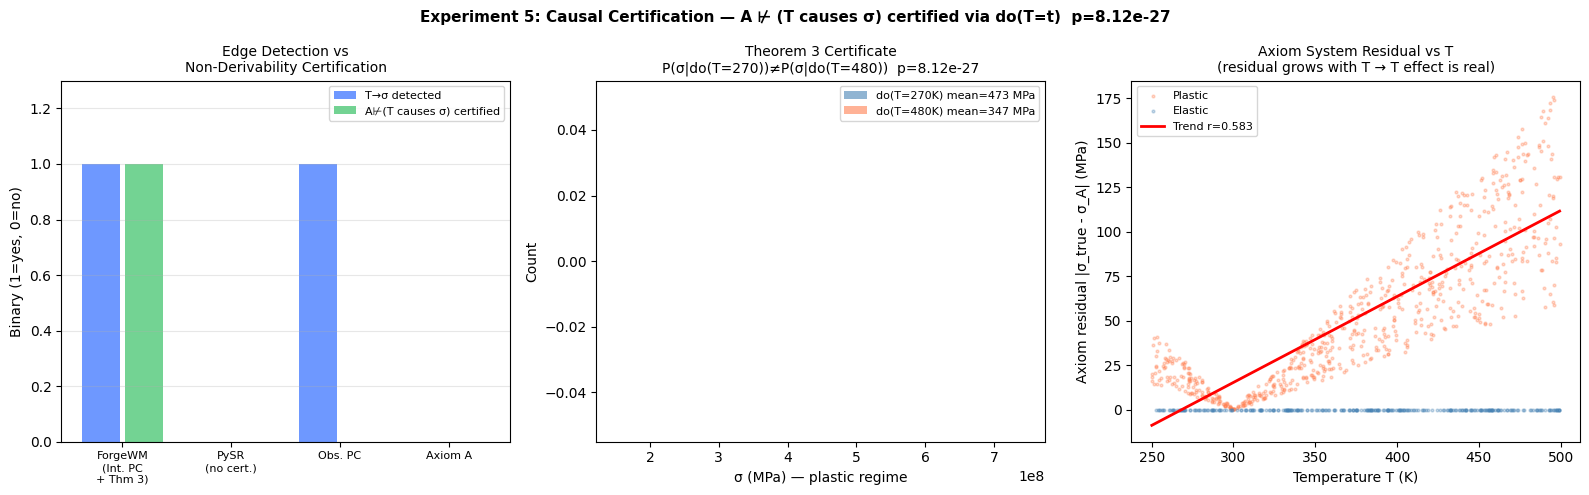

Figure saved: experiment5_certification.png
Results saved: experiment5_results.json


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Certification comparison ─────────────────────────────────
ax = axes[0]
methods = ['ForgeWM\n(Int. PC\n+ Thm 3)',
           'PySR\n(no cert.)',
           'Obs. PC',
           'Axiom A']
certified = [
    baselines5['forgwm_cert']['certifies_T_edge'],
    baselines5['pysr']['certifies_T_edge'],
    baselines5['obs_pc']['certifies_T_edge'],
    baselines5['axiom_A']['certifies_T_edge'],
]
edge_found = [
    baselines5['forgwm_cert']['T_sigma_found'],
    T_in_eq,
    baselines5['obs_pc']['T_sigma_found'],
    False,
]
x = np.arange(len(methods))
ax.bar(x - 0.2, [int(e) for e in edge_found],
       width=0.35, label='T→σ detected', color='#4a7fff', alpha=0.8)
ax.bar(x + 0.2, [int(c) for c in certified],
       width=0.35, label='A⊬(T causes σ) certified',
       color='#50c878', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=8)
ax.set_ylim([0, 1.3])
ax.set_ylabel('Binary (1=yes, 0=no)')
ax.set_title('Edge Detection vs\nNon-Derivability Certification', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# ── Plot 2: Interventional distributions — the certificate ────────────
ax = axes[1]
bins = np.linspace(min(plastic_low.min(), plastic_high.min()),
                   max(plastic_low.max(), plastic_high.max()), 40)
ax.hist(plastic_low  / 1e6, bins=bins, alpha=0.6, color='steelblue',
        label=f'do(T=270K) mean={plastic_low.mean()/1e6:.0f} MPa')
ax.hist(plastic_high / 1e6, bins=bins, alpha=0.6, color='coral',
        label=f'do(T=480K) mean={plastic_high.mean()/1e6:.0f} MPa')
ax.set_xlabel('σ (MPa) — plastic regime')
ax.set_ylabel('Count')
ax.set_title(f'Theorem 3 Certificate\n'
             f'P(σ|do(T=270))≠P(σ|do(T=480))  p={p_ks:.2e}',
             fontsize=10)
ax.legend(fontsize=8)

# ── Plot 3: Axiom residual vs T — visually confirms T effect ──────────
ax = axes[2]
plastic_mask = df_v['epsilon'] > LAMBDA_STAR
ax.scatter(df_v[plastic_mask]['T'],
           df_v[plastic_mask]['residual'] / 1e6,
           s=4, alpha=0.3, c='coral', label='Plastic')
ax.scatter(df_v[~plastic_mask]['T'],
           df_v[~plastic_mask]['residual'] / 1e6,
           s=4, alpha=0.3, c='steelblue', label='Elastic')
# Trend line
T_vals  = df_v[plastic_mask]['T'].values
res_vals= df_v[plastic_mask]['residual'].values / 1e6
z = np.polyfit(T_vals, res_vals, 1)
T_line = np.linspace(T_vals.min(), T_vals.max(), 100)
ax.plot(T_line, np.poly1d(z)(T_line), 'r-', linewidth=2,
        label=f'Trend r={corr_T:.3f}')
ax.set_xlabel('Temperature T (K)')
ax.set_ylabel('Axiom residual |σ_true - σ_A| (MPa)')
ax.set_title('Axiom System Residual vs T\n'
             '(residual grows with T → T effect is real)', fontsize=10)
ax.legend(fontsize=8)

plt.suptitle(
    f'Experiment 5: Causal Certification — '
    f'A ⊬ (T causes σ) certified via do(T=t)  p={p_ks:.2e}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('experiment5_certification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: experiment5_certification.png')

# Save JSON
results5 = {
    'experiment': 5,
    'new_mechanism': 'T → sigma_y (thermal softening)',
    'alpha_T': ALPHA_T,
    'theorem3_certificate': {
        'issued': bool(cert_passed),
        't_stat': float(t_stat),
        'p_ttest': float(p_ttest),
        'ks_stat': float(ks_stat),
        'p_ks': float(p_ks),
        'mean_sigma_T_low_MPa': float(plastic_low.mean()/1e6),
        'mean_sigma_T_high_MPa': float(plastic_high.mean()/1e6)
    },
    'interventional_pc': {
        'T_sigma_found': m_int5['T_sigma_found'],
        'f1': float(m_int5['f1']),
    },
    'baselines': {
        k: {kk: (list(vv) if isinstance(vv, (set, frozenset)) else (bool(vv) if isinstance(vv, np.bool_) else vv))
            for kk, vv in v.items()}
        for k, v in baselines5.items()
    }
}
with open('experiment5_results.json', 'w') as f:
    json.dump(results5, f, indent=2)
print('Results saved: experiment5_results.json')